## OPTIMIZACIÓN DE PORTAFOLIO — MODELO DE MARKOWITZ

Fase 5 Frontera eficiente, portafolio de máximo Sharpe, portafolio de mínima varianza y comparación contra el S&P 500.

Importación de librerías

In [1]:
import sys
print(sys.executable)

c:\Users\ofeli\anaconda3\envs\Finance\python.exe


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

import cvxpy.constraints  # fuerza a que cp.constraints quede disponible

from pypfopt.expected_returns import mean_historical_return
from pypfopt.risk_models import CovarianceShrinkage, sample_cov
from pypfopt.efficient_frontier import EfficientFrontier
from pypfopt import plotting


In [3]:
# ============================================================
# CONFIGURACIÓN
# ============================================================

PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data" / "processed_diversified"
RESULTS_DIR = PROJECT_ROOT / "results" / "markowitz_diversified"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

PRICES_FILE = DATA_DIR / "adjusted_prices.csv"
RETURNS_FILE = DATA_DIR / "daily_returns.csv"
SECTOR_MAP_FILE = DATA_DIR / "sector_map.csv"

RISK_FREE_RATE = 0.02  # ajustar según el benchmark que uses (p.ej. tasa de CETES o T-Bill)
MAX_WEIGHT = 0.15       # con 44 activos esta cota es menos restrictiva que con 20 — considera bajarla si quieres forzar más diversificación
MAX_WEIGHT_TWO = 0.1

benchmark = "^GSPC"

print("Directorio de datos:", DATA_DIR)
print("Directorio de resultados:", RESULTS_DIR)


Directorio de datos: c:\Users\ofeli\Documents\GitHub\Portafolio_investigacion\data\processed_diversified
Directorio de resultados: c:\Users\ofeli\Documents\GitHub\Portafolio_investigacion\results\markowitz_diversified


## Carga y limpieza de datos

Misma limpieza usada en EDA y en el notebook de features: se descartan filas totalmente vacías en `returns` y se alinean los precios al mismo índice.

In [4]:
prices = pd.read_csv(PRICES_FILE, index_col=0, parse_dates=True)
returns = pd.read_csv(RETURNS_FILE, index_col=0, parse_dates=True)

prices.index.name = "Date"
returns.index.name = "Date"

returns_clean = returns.dropna(how="all")
prices_clean = prices.loc[returns_clean.index]

# Markowitz optimiza solo sobre los activos invertibles, no sobre el benchmark
asset_prices = prices_clean.drop(columns=[benchmark])
asset_returns = returns_clean.drop(columns=[benchmark])

print("Activos invertibles:", asset_prices.shape[1])
print("Periodo:", asset_prices.index.min().date(), "→", asset_prices.index.max().date())


Activos invertibles: 44
Periodo: 2018-01-03 → 2026-09-30


### Mapeo de sectores

Con el universo diversificado, cada activo pertenece a uno de 11 sectores GICS. Se carga el mapeo para poder analizar, más adelante, qué tan concentrados o repartidos quedan los pesos óptimos por sector — la pregunta central de este experimento.

In [5]:
sector_map = pd.read_csv(SECTOR_MAP_FILE)
ticker_to_sector = dict(zip(sector_map["ticker"], sector_map["sector"]))

def weights_by_sector(weights: dict) -> pd.Series:
    w = pd.Series(weights)
    sectors = w.index.map(lambda t: ticker_to_sector.get(t, "Otro"))
    return w.groupby(sectors).sum().sort_values(ascending=False)


## 1. Retornos esperados y matriz de covarianza

Se calculan dos versiones de la covarianza para comparar: la muestral simple (la que ya tienes del EDA) y la versión con shrinkage de Ledoit-Wolf, más estable cuando el número de activos es grande relativo al histórico disponible.

In [6]:
mu = mean_historical_return(asset_prices)

S_sample = sample_cov(asset_prices)
S_shrink = CovarianceShrinkage(asset_prices).ledoit_wolf()

print("Retornos esperados anualizados (primeros 5):")
mu.head()


Retornos esperados anualizados (primeros 5):


AAPL    0.274503
ABBV    0.164556
AMT     0.043234
AMZN    0.177008
APD     0.086262
dtype: float64

### Comparación visual: covarianza muestral vs. shrinkage

El shrinkage "jala" los valores extremos de la covarianza muestral hacia el promedio general, reduciendo ruido. Se espera ver menos dispersión en la versión con shrinkage.

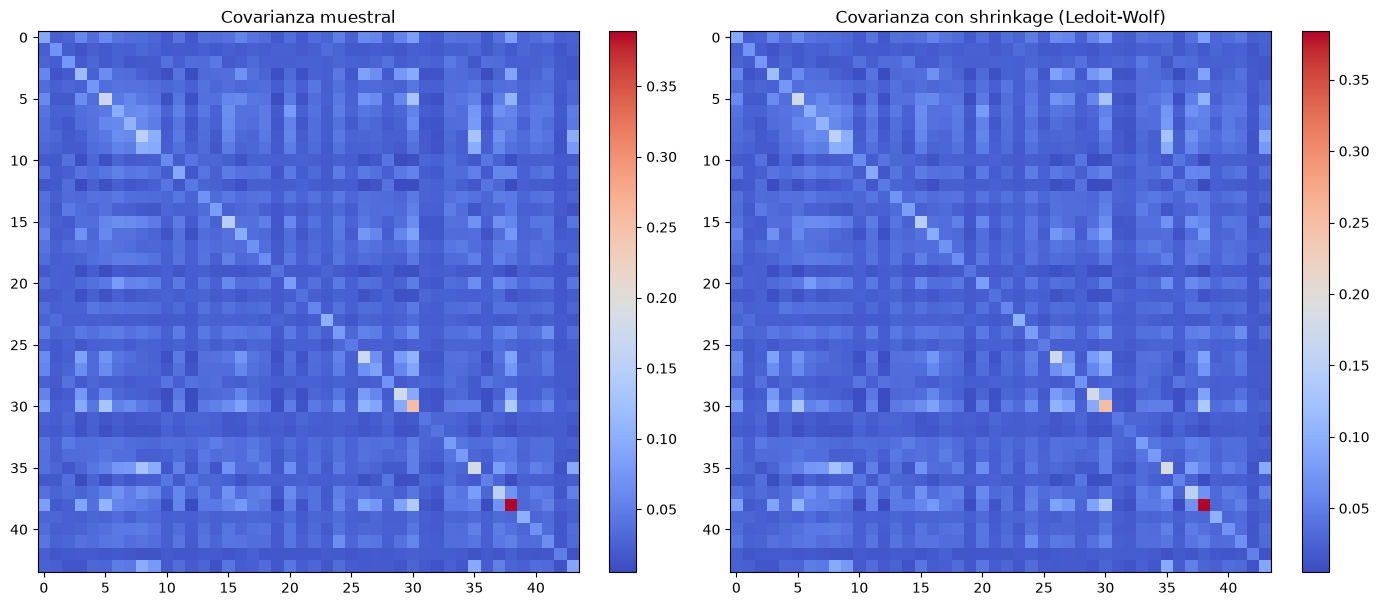

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

im0 = axes[0].imshow(S_sample, cmap="coolwarm")
axes[0].set_title("Covarianza muestral")
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(S_shrink, cmap="coolwarm")
axes[1].set_title("Covarianza con shrinkage (Ledoit-Wolf)")
plt.colorbar(im1, ax=axes[1], fraction=0.046)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "01_covarianza_muestral_vs_shrinkage.png", dpi=300, bbox_inches="tight")
plt.show()


## 2. Frontera eficiente completa

Se grafica la curva completa de frontera eficiente (no solo el punto óptimo), usando la covarianza con shrinkage.

c:\Users\ofeli\anaconda3\envs\Finance\Lib\site-packages\pypfopt\base_optimizer.py:307: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  self._opt.solve(


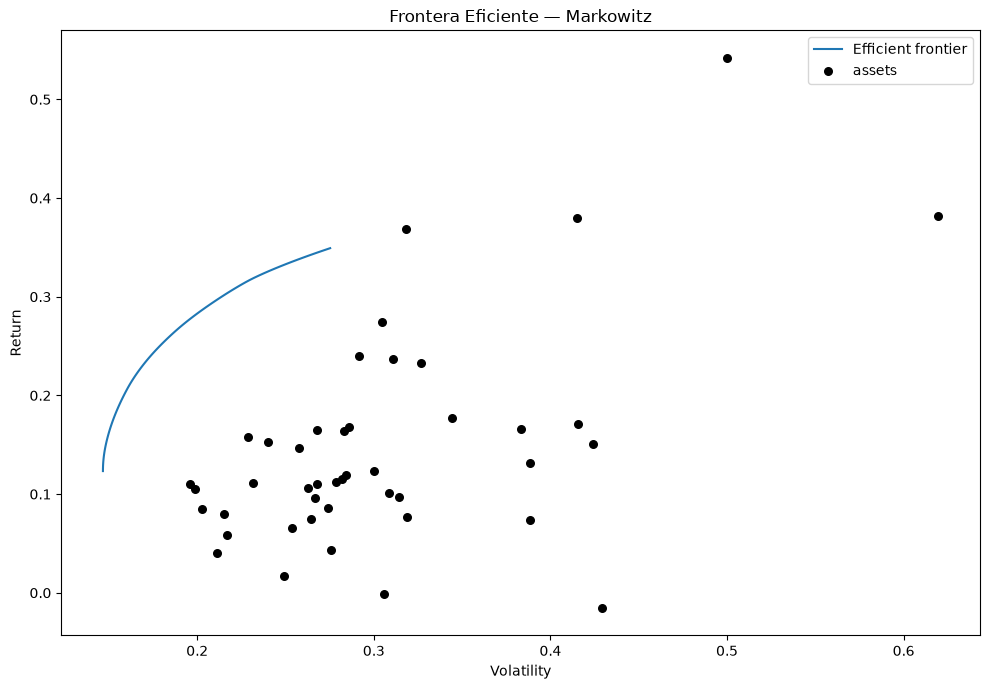

In [8]:
ef_plot = EfficientFrontier(mu, S_shrink, weight_bounds=(0, MAX_WEIGHT))

fig, ax = plt.subplots(figsize=(10, 7))
plotting.plot_efficient_frontier(ef_plot, ax=ax, show_assets=True)
ax.set_title("Frontera Eficiente — Markowitz")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "02_frontera_eficiente.png", dpi=300, bbox_inches="tight")
plt.show()


Cambiando el Max weight

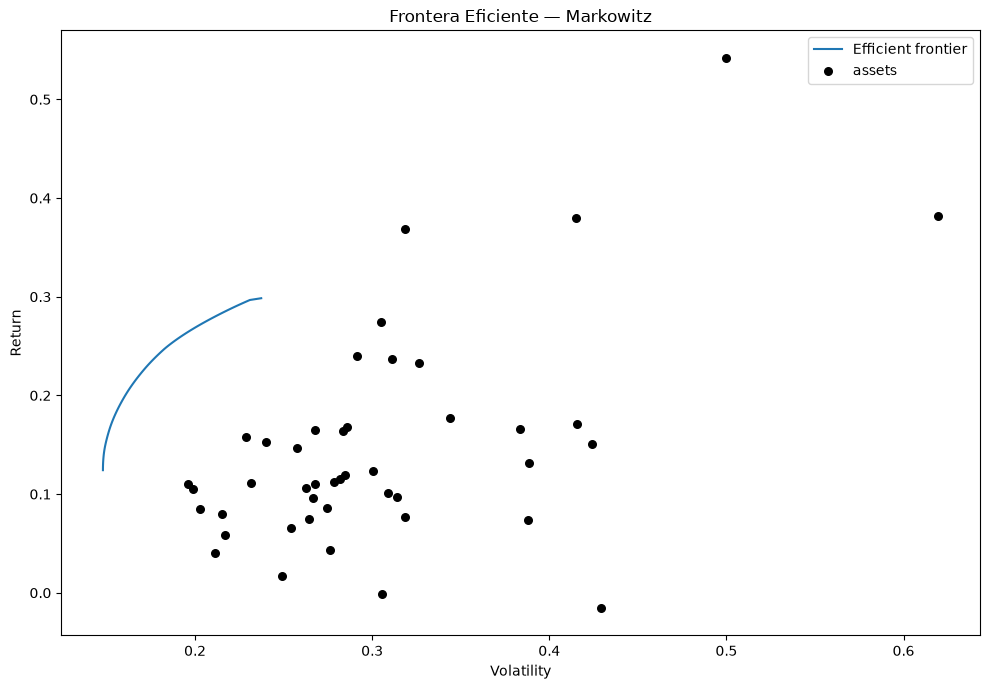

In [9]:
ef_plot_t = EfficientFrontier(mu, S_shrink, weight_bounds=(0, MAX_WEIGHT_TWO))

fig, ax = plt.subplots(figsize=(10, 7))
plotting.plot_efficient_frontier(ef_plot_t, ax=ax, show_assets=True)
ax.set_title("Frontera Eficiente — Markowitz")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "02_frontera_eficiente_t.png", dpi=300, bbox_inches="tight")
plt.show()


## 3. Portafolio de máximo Sharpe (con restricciones)

Restricción de no ventas en corto (`weight_bounds=(0, ...)`) y cota máxima por activo (`MAX_WEIGHT`), para evitar concentración excesiva en un solo emisor.

In [10]:
ef_max_sharpe = EfficientFrontier(mu, S_shrink, weight_bounds=(0, MAX_WEIGHT))

# Cota mínima: si un activo entra al portafolio, debe tener al menos 1% de peso
ef_max_sharpe.add_constraint(lambda w: w >= 0.01)

raw_weights_max_sharpe = ef_max_sharpe.max_sharpe(risk_free_rate=RISK_FREE_RATE)
weights_max_sharpe = ef_max_sharpe.clean_weights()

perf_max_sharpe = ef_max_sharpe.portfolio_performance(
    verbose=True,
    risk_free_rate=RISK_FREE_RATE
)

pd.Series(weights_max_sharpe).sort_values(ascending=False)


Expected annual return: 26.1%
Annual volatility: 20.5%
Sharpe Ratio: 1.18


NVDA     0.15000
LLY      0.15000
WMT      0.13710
AVGO     0.11136
ABBV     0.04437
AAPL     0.02260
TSLA     0.01458
CAT      0.01000
AMZN     0.01000
APD      0.01000
BAC      0.01000
AMT      0.01000
DIS      0.01000
D        0.01000
CVX      0.01000
COP      0.01000
GOOGL    0.01000
DUK      0.01000
EQIX     0.01000
ECL      0.01000
JNJ      0.01000
JPM      0.01000
KO       0.01000
LIN      0.01000
MA       0.01000
HD       0.01000
HON      0.01000
GE       0.01000
MSFT     0.01000
META     0.01000
MCD      0.01000
NEE      0.01000
PG       0.01000
PLD      0.01000
NFLX     0.01000
PEP      0.01000
SLB      0.01000
SHW      0.01000
SPG      0.01000
SO       0.01000
UNH      0.01000
UNP      0.01000
V        0.01000
XOM      0.01000
dtype: float64

In [11]:
ef_max_sharpe_t = EfficientFrontier(mu, S_shrink, weight_bounds=(0, MAX_WEIGHT_TWO))

# Cota mínima: si un activo entra al portafolio, debe tener al menos 1% de peso
ef_max_sharpe_t.add_constraint(lambda w: w >= 0.01)

raw_weights_max_sharpe_t = ef_max_sharpe_t.max_sharpe(risk_free_rate=RISK_FREE_RATE)
weights_max_sharpe_t = ef_max_sharpe_t.clean_weights()

perf_max_sharpe_t = ef_max_sharpe_t.portfolio_performance(
    verbose=True,
    risk_free_rate=RISK_FREE_RATE
)

pd.Series(weights_max_sharpe_t).sort_values(ascending=False)


Expected annual return: 24.2%
Annual volatility: 19.8%
Sharpe Ratio: 1.12


AVGO     0.10000
WMT      0.10000
NVDA     0.10000
LLY      0.10000
AAPL     0.09239
ABBV     0.08869
CAT      0.03159
TSLA     0.02734
AMZN     0.01000
AMT      0.01000
APD      0.01000
BAC      0.01000
DIS      0.01000
D        0.01000
CVX      0.01000
COP      0.01000
GOOGL    0.01000
DUK      0.01000
EQIX     0.01000
ECL      0.01000
JNJ      0.01000
JPM      0.01000
KO       0.01000
LIN      0.01000
MA       0.01000
HD       0.01000
HON      0.01000
GE       0.01000
MSFT     0.01000
META     0.01000
MCD      0.01000
NEE      0.01000
PG       0.01000
PLD      0.01000
NFLX     0.01000
PEP      0.01000
SLB      0.01000
SHW      0.01000
SPG      0.01000
SO       0.01000
UNH      0.01000
UNP      0.01000
V        0.01000
XOM      0.01000
dtype: float64

## 4. Portafolio de mínima varianza

Segundo punto de referencia: el portafolio con menor riesgo posible dentro de las mismas restricciones, sin considerar el retorno esperado.

In [12]:
ef_min_vol = EfficientFrontier(mu, S_shrink, weight_bounds=(0, MAX_WEIGHT))

# Cota mínima: si un activo entra al portafolio, debe tener al menos 1% de peso
ef_min_vol.add_constraint(lambda w: w >= 0.01)

raw_weights_min_vol = ef_min_vol.min_volatility()
weights_min_vol = ef_min_vol.clean_weights()

perf_min_vol = ef_min_vol.portfolio_performance(
    verbose=True,
    risk_free_rate=RISK_FREE_RATE
)

pd.Series(weights_min_vol).sort_values(ascending=False)


Expected annual return: 12.7%
Annual volatility: 15.3%
Sharpe Ratio: 0.70


JNJ      0.15000
WMT      0.14068
KO       0.09490
PG       0.09175
DUK      0.06230
MCD      0.05338
ABBV     0.03700
AVGO     0.01000
APD      0.01000
AAPL     0.01000
AMT      0.01000
AMZN     0.01000
DIS      0.01000
D        0.01000
CVX      0.01000
COP      0.01000
CAT      0.01000
BAC      0.01000
GE       0.01000
GOOGL    0.01000
HON      0.01000
HD       0.01000
LIN      0.01000
JPM      0.01000
LLY      0.01000
MA       0.01000
EQIX     0.01000
ECL      0.01000
MSFT     0.01000
META     0.01000
NVDA     0.01000
NEE      0.01000
PEP      0.01000
PLD      0.01000
SHW      0.01000
NFLX     0.01000
SLB      0.01000
SO       0.01000
TSLA     0.01000
SPG      0.01000
UNH      0.01000
UNP      0.01000
V        0.01000
XOM      0.01000
dtype: float64

In [13]:
ef_min_vol_t = EfficientFrontier(mu, S_shrink, weight_bounds=(0, MAX_WEIGHT_TWO))

# Cota mínima: si un activo entra al portafolio, debe tener al menos 1% de peso
ef_min_vol_t.add_constraint(lambda w: w >= 0.01)

raw_weights_min_vol_t = ef_min_vol_t.min_volatility()
weights_min_vol_t = ef_min_vol_t.clean_weights()

perf_min_vol_t = ef_min_vol_t.portfolio_performance(
    verbose=True,
    risk_free_rate=RISK_FREE_RATE
)

pd.Series(weights_min_vol_t).sort_values(ascending=False)


Expected annual return: 12.7%
Annual volatility: 15.4%
Sharpe Ratio: 0.69


PG       0.10000
WMT      0.10000
KO       0.10000
JNJ      0.10000
DUK      0.09005
MCD      0.07341
ABBV     0.05348
LLY      0.01948
AMZN     0.01359
APD      0.01000
AAPL     0.01000
AMT      0.01000
DIS      0.01000
D        0.01000
CVX      0.01000
COP      0.01000
CAT      0.01000
BAC      0.01000
AVGO     0.01000
GE       0.01000
HON      0.01000
HD       0.01000
GOOGL    0.01000
JPM      0.01000
LIN      0.01000
MA       0.01000
EQIX     0.01000
ECL      0.01000
MSFT     0.01000
META     0.01000
NVDA     0.01000
NEE      0.01000
PEP      0.01000
PLD      0.01000
SHW      0.01000
NFLX     0.01000
SLB      0.01000
SO       0.01000
TSLA     0.01000
SPG      0.01000
UNH      0.01000
UNP      0.01000
V        0.01000
XOM      0.01000
dtype: float64

## 5. Portafolio equal-weight (benchmark ingenuo)

Tercer punto de comparación: pesos iguales entre todos los activos, sin ninguna optimización. Es el benchmark clásico contra el que hay que superar para justificar que la optimización aporta valor.

In [14]:
n_assets = len(asset_prices.columns)
weights_equal = pd.Series(1 / n_assets, index=asset_prices.columns)

weights_equal.head()


AAPL    0.022727
ABBV    0.022727
AMT     0.022727
AMZN    0.022727
APD     0.022727
dtype: float64

## 6. Comparación de pesos entre estrategias

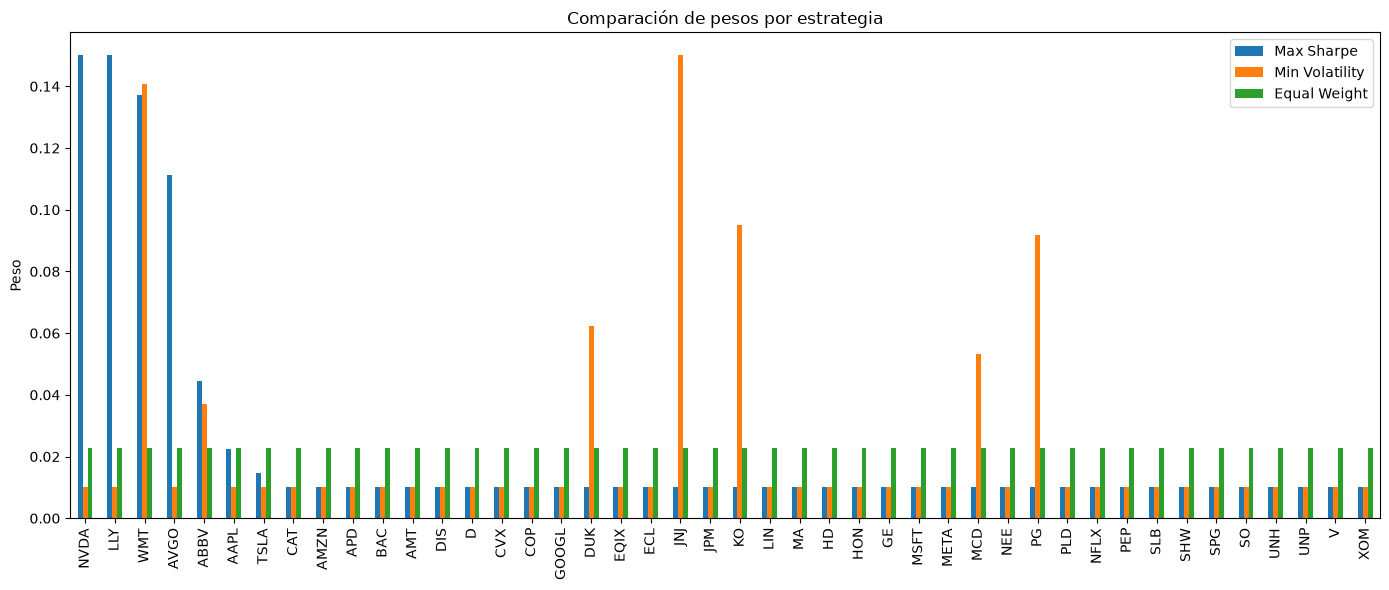

,Max Sharpe,Min Volatility,Equal Weight
NVDA,0.1500,0.0100,0.0227
LLY,0.1500,0.0100,0.0227
WMT,0.1371,0.1407,0.0227
AVGO,0.1114,0.0100,0.0227
ABBV,0.0444,0.0370,0.0227
AAPL,0.0226,0.0100,0.0227
TSLA,0.0146,0.0100,0.0227
CAT,0.0100,0.0100,0.0227
AMZN,0.0100,0.0100,0.0227
APD,0.0100,0.0100,0.0227


In [15]:
weights_comparison = pd.DataFrame({
    "Max Sharpe": pd.Series(weights_max_sharpe),
    "Min Volatility": pd.Series(weights_min_vol),
    "Equal Weight": weights_equal
}).sort_values("Max Sharpe", ascending=False)

weights_comparison.plot(
    kind="bar",
    figsize=(14, 6),
    title="Comparación de pesos por estrategia"
)
plt.ylabel("Peso")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "03_comparacion_pesos.png", dpi=300, bbox_inches="tight")
plt.show()

weights_comparison.round(4)


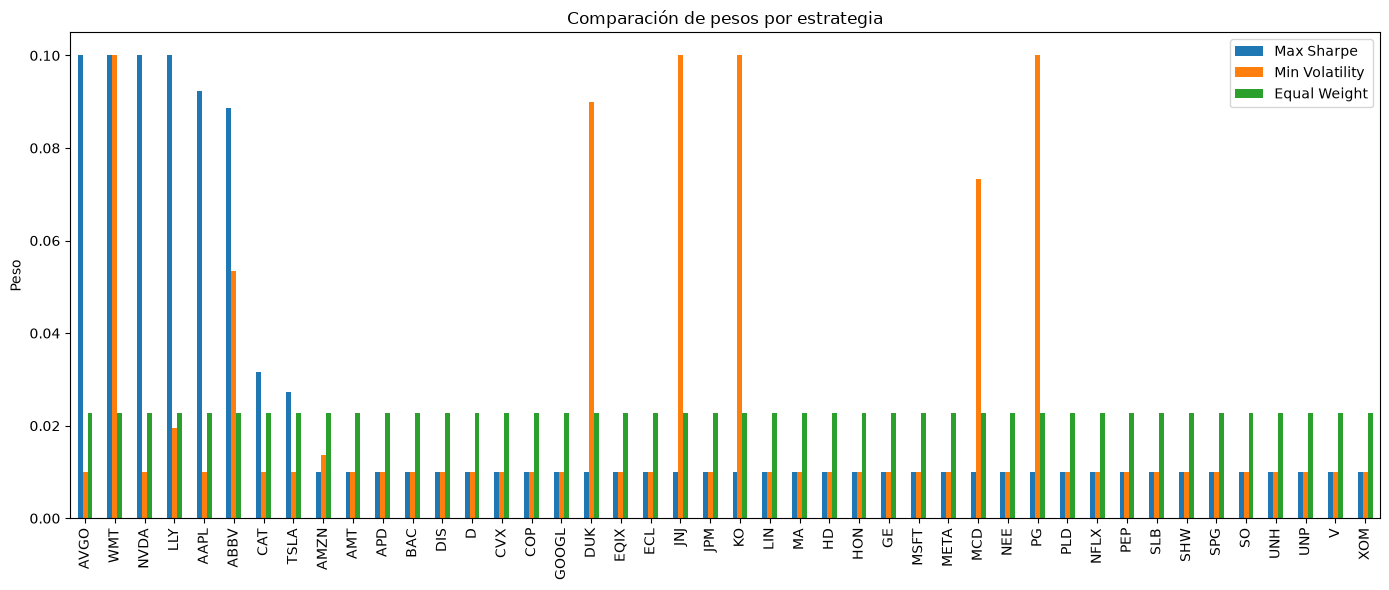

,Max Sharpe,Min Volatility,Equal Weight
AVGO,0.1000,0.0100,0.0227
WMT,0.1000,0.1000,0.0227
NVDA,0.1000,0.0100,0.0227
LLY,0.1000,0.0195,0.0227
AAPL,0.0924,0.0100,0.0227
ABBV,0.0887,0.0535,0.0227
CAT,0.0316,0.0100,0.0227
TSLA,0.0273,0.0100,0.0227
AMZN,0.0100,0.0136,0.0227
AMT,0.0100,0.0100,0.0227


In [16]:
weights_comparison_t = pd.DataFrame({
    "Max Sharpe": pd.Series(weights_max_sharpe_t),
    "Min Volatility": pd.Series(weights_min_vol_t),
    "Equal Weight": weights_equal
}).sort_values("Max Sharpe", ascending=False)

weights_comparison_t.plot(
    kind="bar",
    figsize=(14, 6),
    title="Comparación de pesos por estrategia"
)
plt.ylabel("Peso")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "03_comparacion_pesos.png", dpi=300, bbox_inches="tight")
plt.show()

weights_comparison_t.round(4)


## Composición sectorial de los pesos óptimos

Esta es la pregunta central del experimento de diversificación: con 44 activos repartidos en 11 sectores, ¿Markowitz sigue concentrándose en pocos sectores (p. ej. Tecnología), o la optimización realmente reparte el riesgo entre sectores? Se agrupan los pesos de cada estrategia por sector, para ambas restricciones de cota máxima (15% y 10%).

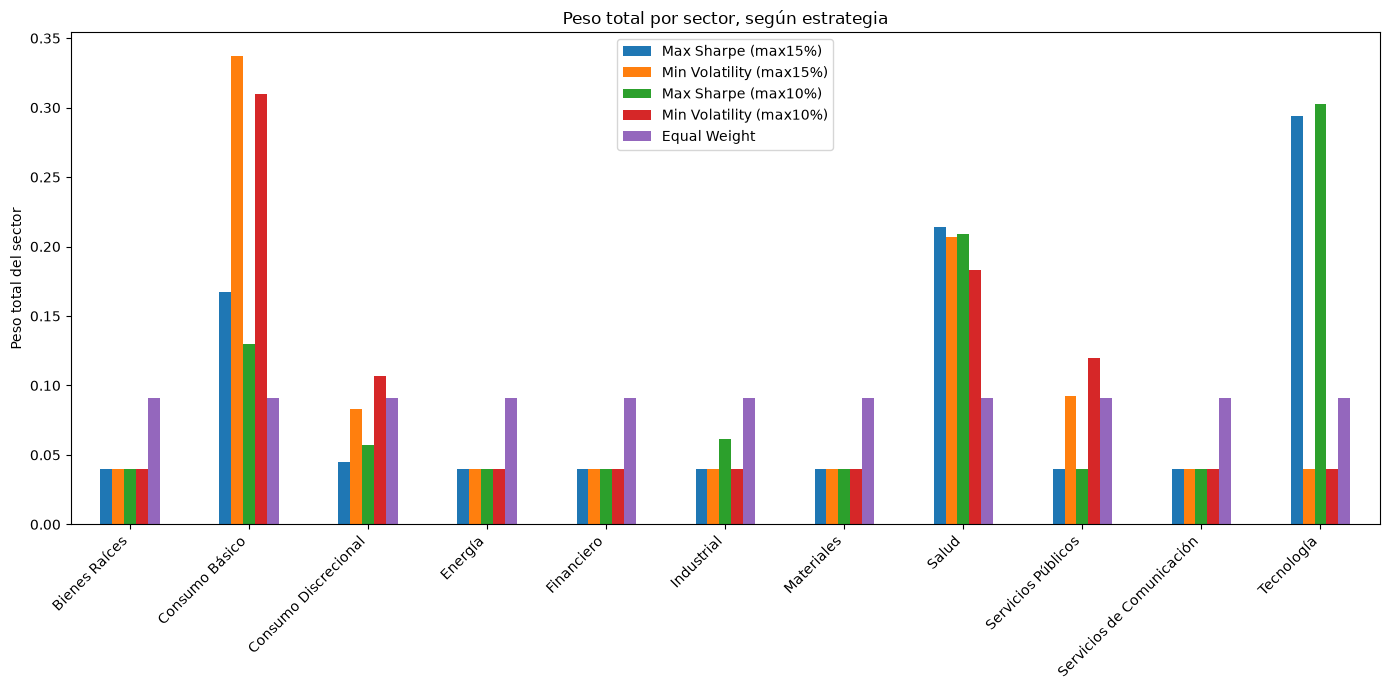

,Max Sharpe (max15%),Min Volatility (max15%),Max Sharpe (max10%),Min Volatility (max10%),Equal Weight
Bienes Raíces,0.0400,0.0400,0.0400,0.040,0.0909
Consumo Básico,0.1671,0.3373,0.1300,0.310,0.0909
Consumo Discrecional,0.0446,0.0834,0.0573,0.107,0.0909
Energía,0.0400,0.0400,0.0400,0.040,0.0909
Financiero,0.0400,0.0400,0.0400,0.040,0.0909
Industrial,0.0400,0.0400,0.0616,0.040,0.0909
Materiales,0.0400,0.0400,0.0400,0.040,0.0909
Salud,0.2144,0.2070,0.2087,0.183,0.0909
Servicios Públicos,0.0400,0.0923,0.0400,0.120,0.0909
Servicios de Comunicación,0.0400,0.0400,0.0400,0.040,0.0909


In [17]:
sector_weights_comparison = pd.DataFrame({
    "Max Sharpe (max15%)": weights_by_sector(weights_max_sharpe),
    "Min Volatility (max15%)": weights_by_sector(weights_min_vol),
    "Max Sharpe (max10%)": weights_by_sector(weights_max_sharpe_t),
    "Min Volatility (max10%)": weights_by_sector(weights_min_vol_t),
    "Equal Weight": weights_by_sector(weights_equal.to_dict())
}).fillna(0)

sector_weights_comparison.plot(
    kind="bar",
    figsize=(14, 7),
    title="Peso total por sector, según estrategia"
)
plt.ylabel("Peso total del sector")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "05_composicion_sectorial.png", dpi=300, bbox_inches="tight")
plt.show()

sector_weights_comparison.round(4)


## 7. Backtest simple contra el S&P 500

Se construyen las series de retorno acumulado de cada estrategia (pesos fijos, sin rebalanceo — eso se aborda formalmente en la Fase 9) y se comparan contra el benchmark.

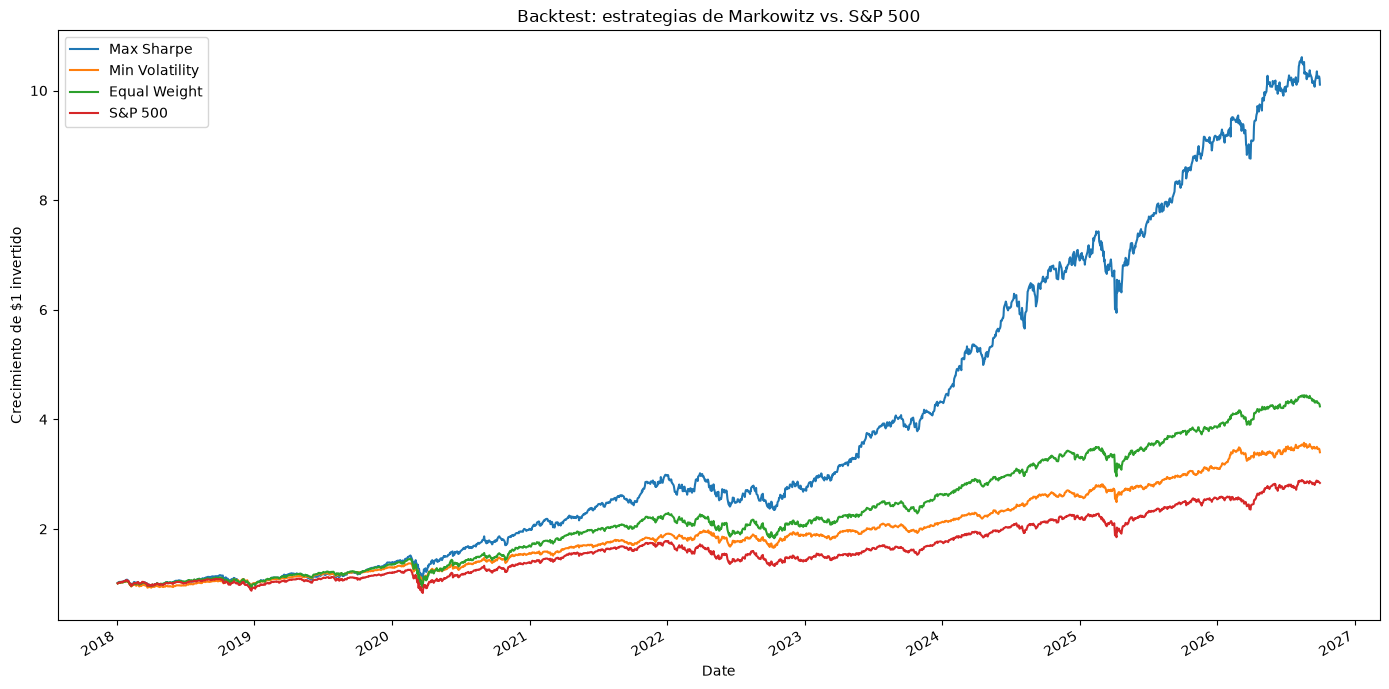

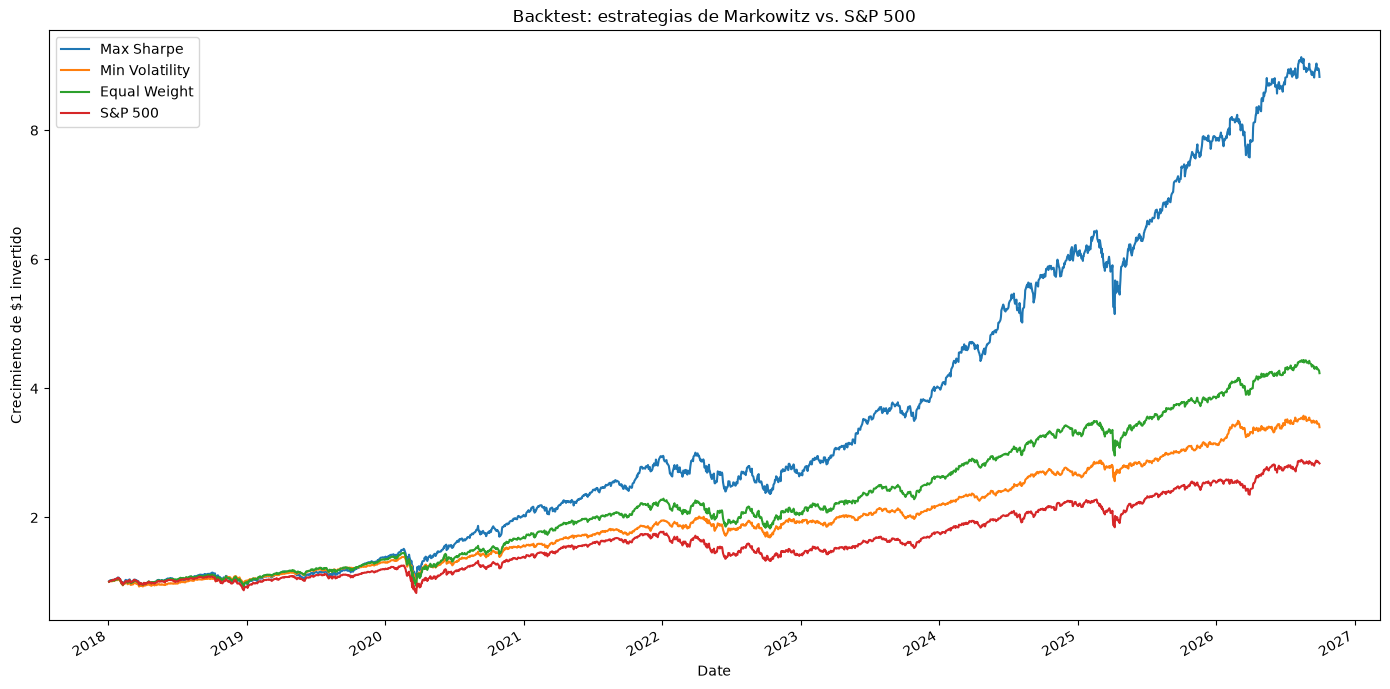

In [18]:
def portfolio_cumulative_return(weights: pd.Series, returns: pd.DataFrame) -> pd.Series:
    aligned_weights = weights.reindex(returns.columns).fillna(0)
    portfolio_returns = (returns * aligned_weights).sum(axis=1)
    return (1 + portfolio_returns).cumprod()

comparison = pd.DataFrame({
    "Max Sharpe": portfolio_cumulative_return(pd.Series(weights_max_sharpe), asset_returns),
    "Min Volatility": portfolio_cumulative_return(pd.Series(weights_min_vol), asset_returns),
    "Equal Weight": portfolio_cumulative_return(weights_equal, asset_returns),
    "S&P 500": (1 + returns_clean[benchmark]).cumprod()
})

comparison.plot(figsize=(14, 7), title="Backtest: estrategias de Markowitz vs. S&P 500")
plt.ylabel("Crecimiento de $1 invertido")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "04_backtest_vs_sp500.png", dpi=300, bbox_inches="tight")
plt.show()

def portfolio_cumulative_return_t(weights: pd.Series, returns: pd.DataFrame) -> pd.Series:
    aligned_weights_t = weights.reindex(returns.columns).fillna(0)
    portfolio_returns_t = (returns * aligned_weights_t).sum(axis=1)
    return (1 + portfolio_returns_t).cumprod()

comparison_t = pd.DataFrame({
    "Max Sharpe": portfolio_cumulative_return(pd.Series(weights_max_sharpe_t), asset_returns),
    "Min Volatility": portfolio_cumulative_return(pd.Series(weights_min_vol_t), asset_returns),
    "Equal Weight": portfolio_cumulative_return(weights_equal, asset_returns),
    "S&P 500": (1 + returns_clean[benchmark]).cumprod()
})

comparison_t.plot(figsize=(14, 7), title="Backtest: estrategias de Markowitz vs. S&P 500")
plt.ylabel("Crecimiento de $1 invertido")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "04_backtest_vs_sp500_t.png", dpi=300, bbox_inches="tight")
plt.show()


## 8. Tabla resumen de métricas por estrategia

In [19]:
def annualized_metrics(cum_returns: pd.Series, risk_free_rate: float = RISK_FREE_RATE) -> dict:
    daily_returns = cum_returns.pct_change().dropna()
    ann_return = daily_returns.mean() * 252
    ann_vol = daily_returns.std() * np.sqrt(252)
    sharpe = (ann_return - risk_free_rate) / ann_vol
    max_drawdown = (cum_returns / cum_returns.cummax() - 1).min()
    return {
        "Retorno anualizado": ann_return,
        "Volatilidad anualizada": ann_vol,
        "Sharpe Ratio": sharpe,
        "Máximo Drawdown": max_drawdown
    }

summary = pd.DataFrame({
    col: annualized_metrics(comparison[col]) for col in comparison.columns
}).T

summary.round(4)



,Retorno anualizado,Volatilidad anualizada,Sharpe Ratio,Máximo Drawdown
Max Sharpe,0.2852,0.2061,1.2863,-0.2848
Min Volatility,0.1517,0.1538,0.8565,-0.2908
Equal Weight,0.1818,0.1826,0.8860,-0.3542
S&P 500,0.1374,0.1914,0.6133,-0.3392


In [20]:

def annualized_metrics_t(cum_returns: pd.Series, risk_free_rate: float = RISK_FREE_RATE) -> dict:
    daily_returns_t = cum_returns.pct_change().dropna()
    ann_return_t = daily_returns_t.mean() * 252
    ann_vol_t = daily_returns_t.std() * np.sqrt(252)
    sharpe_t = (ann_return_t - risk_free_rate) / ann_vol_t
    max_drawdown_t = (cum_returns / cum_returns.cummax() - 1).min()
    return {
        "Retorno anualizado": ann_return_t,
        "Volatilidad anualizada": ann_vol_t,
        "Sharpe Ratio": sharpe_t,
        "Máximo Drawdown": max_drawdown_t
    }

summary_t = pd.DataFrame({
    col: annualized_metrics_t(comparison_t[col]) for col in comparison_t.columns
}).T

summary_t.round(4)

,Retorno anualizado,Volatilidad anualizada,Sharpe Ratio,Máximo Drawdown
Max Sharpe,0.2687,0.1999,1.2443,-0.3036
Min Volatility,0.1519,0.1547,0.8532,-0.3042
Equal Weight,0.1818,0.1826,0.8860,-0.3542
S&P 500,0.1374,0.1914,0.6133,-0.3392


## 9. Guardar resultados

In [21]:
pd.Series(weights_max_sharpe).to_csv(RESULTS_DIR / "weights_max_sharpe.csv")
pd.Series(weights_min_vol).to_csv(RESULTS_DIR / "weights_min_volatility.csv")
comparison.to_csv(RESULTS_DIR / "backtest_comparison.csv")
summary.to_csv(RESULTS_DIR / "summary_metrics.csv")

print("Resultados guardados en:", RESULTS_DIR)


Resultados guardados en: c:\Users\ofeli\Documents\GitHub\Portafolio_investigacion\results\markowitz_diversified
